<a href="https://colab.research.google.com/github/vkantimahanti/healthcare-ml-portfolio/blob/main/Algorithm_Comparison_Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install mlflow shap -q

'''
mlflow - Installs MLflow, an open-source platform used to manage the machine learning lifecycle, including experiment tracking, model packaging, and deployment.
shap - Installs SHAP (SHapley Additive exPlanations), a library used for "model explainability." it helps you understand how different features in your data contribute to a model's specific predictions.
-q -  A flag that tells pip to be "quiet." It hides non-error messages (like progress bars and successful download notifications) to keep your terminal or notebook output clean.
'''

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Load the diabetes dataset
# This is a REGRESSION task: predict disease progression score
# 442 patients, 10 clinical features (age, sex, BMI, blood pressure, etc.)

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='disease_progression')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Data loaded ✓")

Data loaded ✓


In [8]:
# Cross-validation splits data into 5 folds
# Trains on 4 folds, tests on 1 — repeats 5 times
# Gives you 5 scores — average them for a reliable number

'''
Think of this code as a "Stress Test" for your model.
Instead of trusting the model after testing it just once, you are testing it five different times on different slices of your data to make sure its performance isn't just a fluke.
1. The Strategy: cross_val_score
The cv=5 tells the computer to perform 5-Fold Cross-Validation:
It splits your data into 5 equal piles.
It trains the model 5 times. Each time, it uses 4 piles for learning and the 1 remaining pile for testing.
By the end, every single piece of data has been used as a "test" once.
'''

rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("Cross-validation R² scores across 5 folds:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.3f}")

print(f"\nMean R²  : {cv_scores.mean():.3f}")  # This is the average score across all 5 tests. It’s a much more "honest" number than a single test score because it accounts for the entire dataset.
print(f"Std Dev  : {cv_scores.std():.3f}  (lower = more stable model)") # Low Std Dev: The model performs roughly the same regardless of which data it sees (it's stable). High Std Dev: The model is "moody"—it does great on some data but fails on others (it's unreliable).
print(f"\nsingle split R²: 0.441")
print(f"CV mean R²           : {cv_scores.mean():.3f}  ← more trustworthy")

Cross-validation R² scores across 5 folds:
  Fold 1: 0.390
  Fold 2: 0.522
  Fold 3: 0.457
  Fold 4: 0.335
  Fold 5: 0.445

Mean R²  : 0.430
Std Dev  : 0.063  (lower = more stable model)

single split R²: 0.441
CV mean R²           : 0.430  ← more trustworthy


In [9]:
'''

Overfitting vs underfitting — the most important concept in ML
Overfitting = model memorizes training data, fails on new patients. Symptom: train score 0.95, test score 0.44. Your max_depth controls this in Random Forest — deeper tree = more memorization.

Underfitting = model too simple, misses real patterns. Symptom: both train and test scores are low.

Sweet spot = train and test scores are close to each other. That's what cross-validation helps you find.

'''

# This is how you DETECT overfitting
# If train score >> test score → overfitting → reduce max_depth

rf.fit(X_train, y_train)

train_r2 = r2_score(y_train, rf.predict(X_train))
test_r2  = r2_score(y_test,  rf.predict(X_test))
gap      = train_r2 - test_r2

print(f"Train R²  : {train_r2:.3f}")
print(f"Test R²   : {test_r2:.3f}")
print(f"Gap       : {gap:.3f}")
print()

if gap > 0.15:
    print("⚠ Overfitting detected — try smaller max_depth")
elif test_r2 < 0.3:
    print("⚠ Underfitting — model too simple, try deeper tree")
else:
    print("✓ Reasonable fit — gap is acceptable")

Train R²  : 0.741
Test R²   : 0.456
Gap       : 0.284

⚠ Overfitting detected — try smaller max_depth


In [11]:
# SVM needs scaled features — wrap it in a Pipeline
# Others work fine on raw features
# This is your answer to "why not SVM on Day 1" — extra setup needed

models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'SVM'               : Pipeline([
                              ('scaler', StandardScaler()),
                              ('svm', SVR(kernel='rbf'))
                          ])
}

results = []
for name, model in models.items():
    cv  = cross_val_score(model, X, y, cv=5, scoring='r2')
    model.fit(X_train, y_train)
    tr  = r2_score(y_train, model.predict(X_train))
    te  = r2_score(y_test,  model.predict(X_test))
    mae = mean_absolute_error(y_test, model.predict(X_test))
    results.append({
        'Model'        : name,
        'CV Mean R²'   : round(cv.mean(), 3),
        'Train R²'     : round(tr, 3),
        'Test R²'      : round(te, 3),
        'Overfit Gap'  : round(tr - te, 3),
        'MAE'          : round(mae, 1)
    })

df_results = pd.DataFrame(results).sort_values('CV Mean R²', ascending=False)
print(df_results.to_string(index=False))

            Model  CV Mean R²  Train R²  Test R²  Overfit Gap  MAE
Linear Regression       0.482     0.528    0.453        0.075 42.8
    Random Forest       0.430     0.741    0.456        0.284 43.6
    Decision Tree       0.206     0.669    0.334        0.334 45.9
              SVM       0.147     0.167    0.182       -0.015 56.0


In [12]:
mlflow.set_experiment("diabetes-model-comparison")

for name, model in models.items():
    with mlflow.start_run(run_name=name.lower().replace(' ', '-')):
        model.fit(X_train, y_train)
        preds  = model.predict(X_test)
        r2     = r2_score(y_test, preds)
        mae    = mean_absolute_error(y_test, preds)
        cv     = cross_val_score(model, X, y, cv=5, scoring='r2')

        mlflow.log_param("model_type", name)
        mlflow.log_metric("r2_test",  round(r2, 3))
        mlflow.log_metric("mae",       round(mae, 1))
        mlflow.log_metric("cv_mean_r2", round(cv.mean(), 3))
        mlflow.log_metric("cv_std",    round(cv.std(), 3))
        mlflow.sklearn.log_model(model, name.lower().replace(' ','-'))

        print(f"Logged: {name:20s} | CV R²: {cv.mean():.3f} | MAE: {mae:.1f}")

print("\nAll 4 models logged to MLflow ✓")

2026/03/14 19:38:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/14 19:38:58 INFO mlflow.store.db.utils: Updating database tables
2026/03/14 19:39:00 INFO mlflow.tracking.fluent: Experiment with name 'diabetes-model-comparison' does not exist. Creating a new experiment.
2026/03/14 19:39:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 19:39:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/14 19:39:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged: Linear Regression    | CV R²: 0.482 | MAE: 42.8


2026/03/14 19:39:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: Decision Tree        | CV R²: 0.206 | MAE: 45.9


2026/03/14 19:39:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 19:39:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: Random Forest        | CV R²: 0.430 | MAE: 43.6


2026/03/14 19:39:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 19:39:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: SVM                  | CV R²: 0.147 | MAE: 56.0

All 4 models logged to MLflow ✓


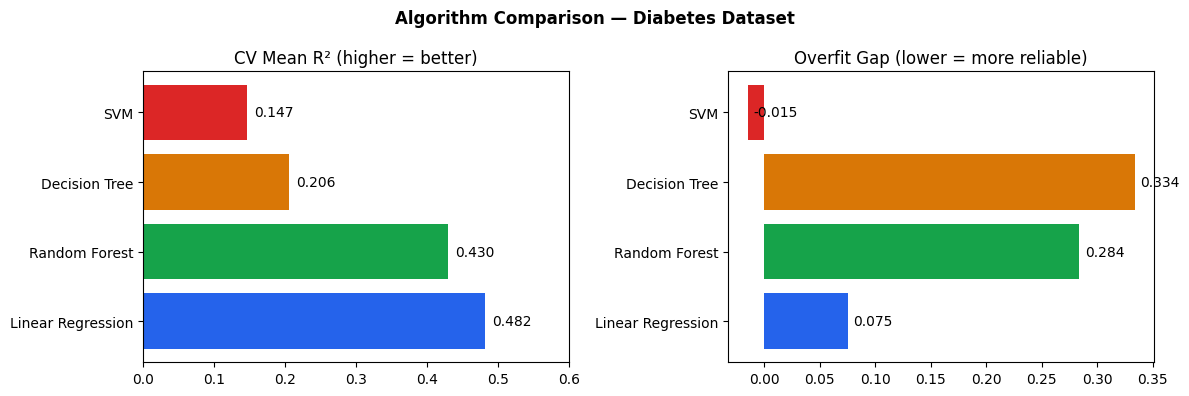

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2563eb', '#16a34a', '#d97706', '#dc2626']
names  = df_results['Model'].tolist()

# Plot 1 — CV R² comparison
axes[0].barh(names, df_results['CV Mean R²'], color=colors)
axes[0].set_title('CV Mean R² (higher = better)')
axes[0].set_xlim(0, 0.6)
for i, v in enumerate(df_results['CV Mean R²']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

# Plot 2 — Overfit gap (train - test)
axes[1].barh(names, df_results['Overfit Gap'], color=colors)
axes[1].set_title('Overfit Gap (lower = more reliable)')
for i, v in enumerate(df_results['Overfit Gap']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.suptitle('Algorithm Comparison — Diabetes Dataset', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()